In [1]:
import pandas as pd
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define our paths
zip_path = '/content/drive/MyDrive/MRI_PET_10_FEB_ADNI2.zip'
mri_base_dir = '/content/drive/MyDrive/ADNI_MRI_Only'

# Create the output folders for our 2D MRI images
os.makedirs(f"{mri_base_dir}/AD", exist_ok=True)
os.makedirs(f"{mri_base_dir}/CN", exist_ok=True)

# 3. Load the CSV from GOOGLE DRIVE (Notice the updated path here!)
# If you put the CSV inside a specific folder in your Drive, update this path.
csv_filename = '/content/drive/MyDrive/MRI_PET_10_FEB_ADNI2_2_10_2026.csv'
df = pd.read_csv(csv_filename)

# 4. Filter for ONLY MRI scans
mri_df = df[df['Modality'] == 'MRI']

# Create our dictionary for instant label lookup (Image ID -> AD or CN)
mri_label_map = dict(zip(mri_df['Image Data ID'], mri_df['Group']))

print(f"Setup Complete! Found {len(mri_label_map)} MRI scans in the CSV.")
print("Drive mounted and folders created.")

Mounted at /content/drive
Setup Complete! Found 720 MRI scans in the CSV.
Drive mounted and folders created.


In [2]:
import zipfile
import nibabel as nib
import numpy as np
import cv2
import re

print("Starting MRI 3D to 2D Conversion...")

count = 0
with zipfile.ZipFile(zip_path, 'r') as zf:
    all_files = zf.namelist()

    # Loop through every file in the ZIP
    for f in all_files:
        # Only look at NIfTI files
        if f.endswith('.nii') or f.endswith('.nii.gz'):

            # Find the 'I123456' ID in the filename
            img_id_match = re.search(r'I\d+', f)
            if img_id_match:
                img_id = img_id_match.group(0)

                # If this ID is in our MRI CSV list, process it
                if img_id in mri_label_map:
                    group = mri_label_map[img_id]
                    save_path = f"{mri_base_dir}/{group}/{img_id}.png"

                    # Skip if we already processed it (in case Colab disconnects)
                    if not os.path.exists(save_path):
                        # Extract temporarily
                        zf.extract(f, '/content/temp')
                        local_path = os.path.join('/content/temp', f)

                        try:
                            # Load 3D and get middle slice
                            img = nib.load(local_path)
                            data = img.get_fdata()

                            # Handle 4D if it exists
                            if data.ndim == 4: data = data[:,:,:,0]

                            # Middle slice
                            mid = data.shape[2] // 2
                            slice_2d = data[:, :, mid]

                            # Normalize 0-255
                            denom = np.max(slice_2d) - np.min(slice_2d)
                            if denom == 0: denom = 1
                            slice_2d = (slice_2d - np.min(slice_2d)) / denom * 255

                            # Save as PNG
                            cv2.imwrite(save_path, slice_2d.astype(np.uint8))
                            count += 1

                            if count % 20 == 0:
                                print(f"Successfully processed {count} MRI images...")

                        except Exception as e:
                            print(f"Error on {img_id}: {e}")

                        finally:
                            # Always delete temp file to save space
                            if os.path.exists(local_path):
                                os.remove(local_path)

print(f"MRI Preprocessing Complete! Total processed: {count}")

Starting MRI 3D to 2D Conversion...
Successfully processed 20 MRI images...
Successfully processed 40 MRI images...
Successfully processed 60 MRI images...
Successfully processed 80 MRI images...
Successfully processed 100 MRI images...
Successfully processed 120 MRI images...
Successfully processed 140 MRI images...
Successfully processed 160 MRI images...
Successfully processed 180 MRI images...
Successfully processed 200 MRI images...
Successfully processed 220 MRI images...
Successfully processed 240 MRI images...
Successfully processed 260 MRI images...
Successfully processed 280 MRI images...
Successfully processed 300 MRI images...
Successfully processed 320 MRI images...
Successfully processed 340 MRI images...
Successfully processed 360 MRI images...
Successfully processed 380 MRI images...
Successfully processed 400 MRI images...
Successfully processed 420 MRI images...
Successfully processed 440 MRI images...
Successfully processed 460 MRI images...
Successfully processed 48

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Path to your extracted 2D MRI images
mri_base_dir = '/content/drive/MyDrive/ADNI_MRI_Only'

# 2. Image Parameters (Resizing all images to a standard 224x224)
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

# 3. Create the Data Generator
# We add a slight rotation/zoom (Data Augmentation) to artificially increase our dataset
# size and prevent the model from memorizing the images (overfitting).
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to between 0 and 1
    validation_split=0.2,    # Reserve 20% for testing
    rotation_range=10,       # Rotate slightly
    zoom_range=0.1           # Zoom slightly
)

print("Loading Training Data:")
train_generator = datagen.flow_from_directory(
    mri_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',     # 'binary' because we only have 2 classes: AD and CN
    subset='training'
)

print("\nLoading Validation Data:")
val_generator = datagen.flow_from_directory(
    mri_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Loading Training Data:
Found 576 images belonging to 2 classes.

Loading Validation Data:
Found 143 images belonging to 2 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN Architecture
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Drops 50% of connections randomly to prevent overfitting
    Dense(1, activation='sigmoid') # Sigmoid outputs a probability between 0 and 1
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print the architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Starting Model Training...")

EPOCHS = 15 # Number of times the model will see the entire dataset

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

print("Training Complete!")

Starting Model Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 183s 5s/step - accuracy: 0.5300 - loss: 0.8677 - val_accuracy: 0.5804 - val_loss: 0.6890
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 305ms/step - accuracy: 0.5799 - loss: 0.6808 - val_accuracy: 0.5804 - val_loss: 0.6940
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.5530 - loss: 0.6850 - val_accuracy: 0.5664 - val_loss: 0.6988
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.5972 - loss: 0.6728 - val_accuracy: 0.5804 - val_loss: 0.6967
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 304ms/step - accuracy: 0.6390 - loss: 0.6298 - val_accuracy: 0.5175 - val_loss: 0.6972
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - accuracy: 0.6597 - loss: 0.6442 - val_accuracy: 0.5664 - val_loss: 0.7110
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 306ms/step - accuracy: 0.6298 - loss: 0.6478 - val_accuracy: 0.4895 - val_loss: 0.7225
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 302ms/step - accuracy: 0.6585 - loss: 0.6178 - val_accura

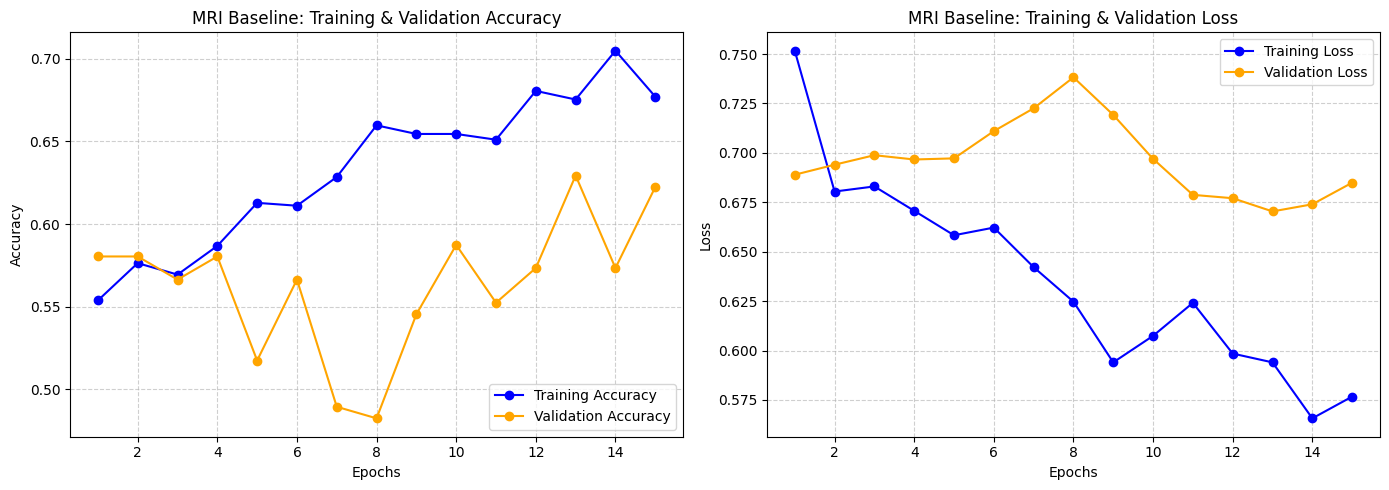

Generating predictions for Confusion Matrix...
Found 143 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step


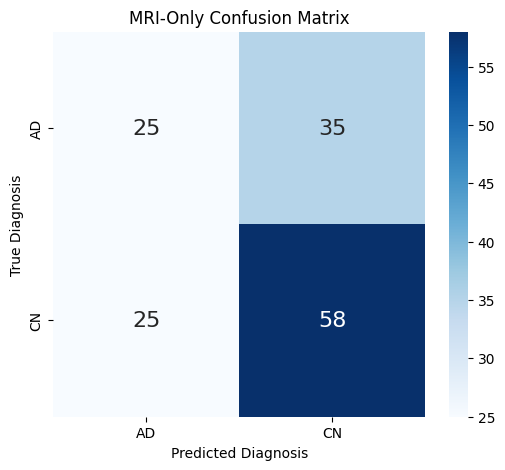


 MRI-ONLY BASELINE CLASSIFICATION REPORT
              precision    recall  f1-score   support

          AD       0.50      0.42      0.45        60
          CN       0.62      0.70      0.66        83

    accuracy                           0.58       143
   macro avg       0.56      0.56      0.56       143
weighted avg       0.57      0.58      0.57       143



In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. Plot Training vs. Validation Graphs
# ---------------------------------------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='orange')
plt.title('MRI Baseline: Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='orange')
plt.title('MRI Baseline: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Prepare Data for Confusion Matrix
# ---------------------------------------------------------
print("Generating predictions for Confusion Matrix...")

# We MUST recreate the validation generator with shuffle=False
# so the predicted labels match up perfectly with the true labels.
val_generator_eval = datagen.flow_from_directory(
    mri_base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Get predictions from the model
predictions = model.predict(val_generator_eval)
# Convert probabilities to 0 (CN) or 1 (AD)
predicted_classes = (predictions > 0.5).astype("int32")
true_classes = val_generator_eval.classes
class_labels = list(val_generator_eval.class_indices.keys())

# ---------------------------------------------------------
# 3. Plot Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 16})
plt.title('MRI-Only Confusion Matrix')
plt.ylabel('True Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

# ---------------------------------------------------------
# 4. Print the Official Classification Report
# ---------------------------------------------------------
print("\n" + "="*50)
print(" MRI-ONLY BASELINE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_classes, predicted_classes, target_names=class_labels))